# TrekTrak — Initial Data Analysis

Exploratory analysis of one or more days of simulated sensor data collected via `simulation.py --csv`.

**Data columns:**
| Column | Description |
|---|---|
| `timestamp` | ISO-8601 UTC timestamp (end of 15-min window) |
| `us_detections` | Ultrasonic detection count in the window |
| `us_presence_sec` | Total seconds of detected presence |
| `pir_triggers` | PIR motion trigger count |
| `intensity` | Ground-truth traffic intensity (0–1, from model) |
| `gps_lat/lon` | Sensor GPS coordinates |
| `uptime_sec` | Sensor uptime in seconds |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['figure.dpi'] = 110
sns.set_theme(style='whitegrid')

CSV_PATH = '../data/sim.csv'

## 1  Load & Inspect

In [2]:
df = pd.read_csv(CSV_PATH, parse_dates=['timestamp'])
df = df.set_index('timestamp').sort_index()

print(f'Shape: {df.shape}')
print(f'Time range: {df.index.min()}  →  {df.index.max()}')
print(f'Duration: {df.index.max() - df.index.min()}')
df.head()

Shape: (96, 8)
Time range: 2026-04-24 00:15:00+00:00  →  2026-04-25 00:00:00+00:00
Duration: 0 days 23:45:00


,seq,gps_lat,gps_lon,us_detections,us_presence_sec,pir_triggers,uptime_sec,intensity
timestamp,,,,,,,,
2026-04-24 00:15:00+00:00,1,42.504794,-71.195595,0,0.0,0,900,0.02
2026-04-24 00:30:00+00:00,2,42.504792,-71.195602,0,0.0,0,1800,0.02
2026-04-24 00:45:00+00:00,3,42.504800,-71.195609,0,0.0,0,2700,0.02
2026-04-24 01:00:00+00:00,4,42.504801,-71.195606,0,0.0,2,3600,0.02
2026-04-24 01:15:00+00:00,5,42.504790,-71.195594,0,0.0,0,4500,0.02


## 2  Descriptive Statistics

In [3]:
sensor_cols = ['us_detections', 'us_presence_sec', 'pir_triggers']
stats = df[sensor_cols].describe().T
stats.columns = ['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']
stats['units'] = ['count', 'seconds', 'count']
stats.round(2)

,count,mean,std,min,25%,50%,75%,max,units
us_detections,96.0,3.44,4.83,0.0,0.0,1.00,6.0,22.0,count
us_presence_sec,96.0,17.01,21.72,0.0,0.0,4.05,30.9,79.2,seconds
pir_triggers,96.0,5.45,6.60,0.0,0.0,2.50,9.0,28.0,count


## 3  Time-Series Overview

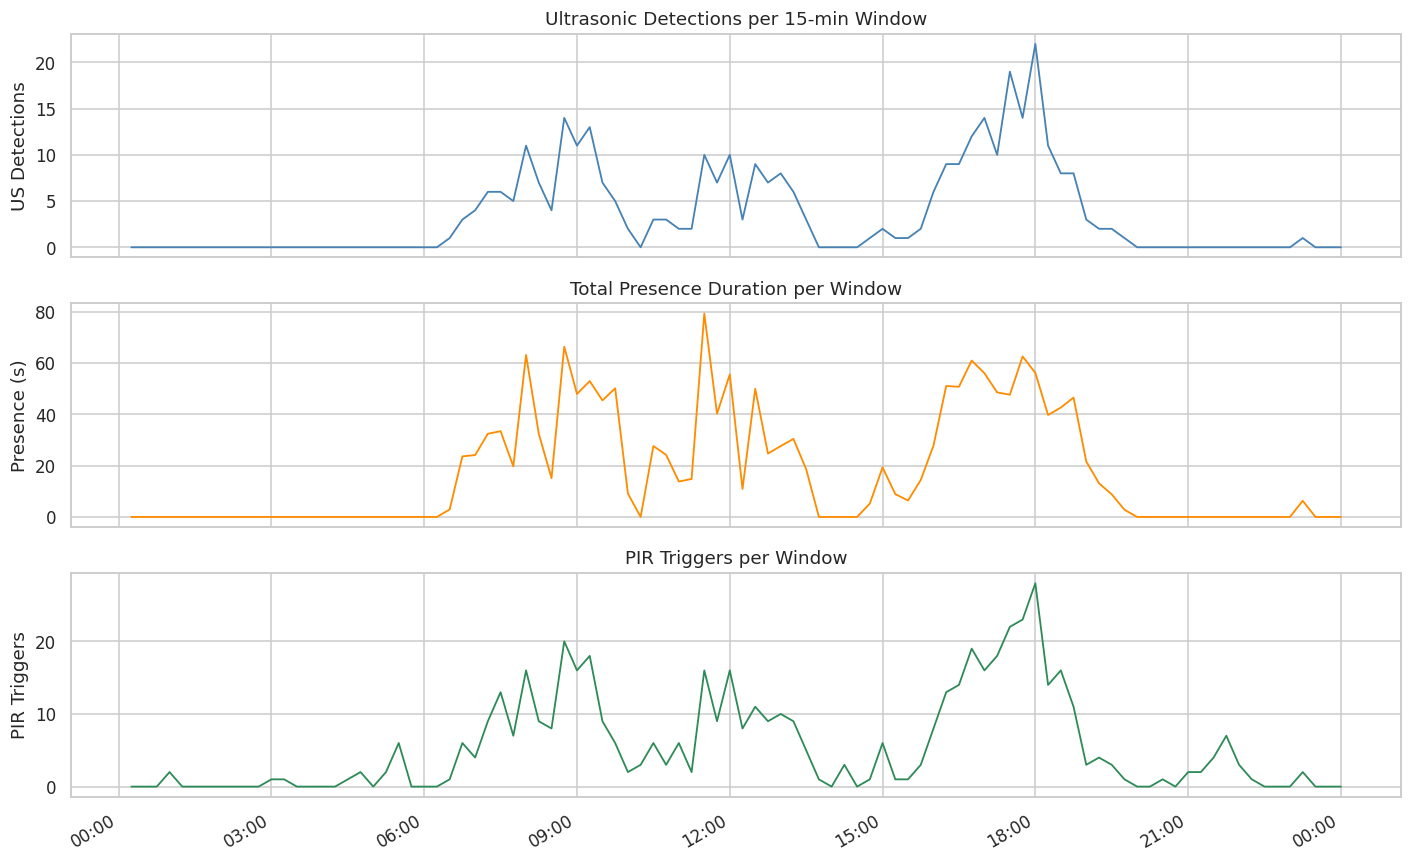

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True)

axes[0].plot(df.index, df['us_detections'], color='steelblue', linewidth=1.2)
axes[0].set_ylabel('US Detections')
axes[0].set_title('Ultrasonic Detections per 15-min Window')

axes[1].plot(df.index, df['us_presence_sec'], color='darkorange', linewidth=1.2)
axes[1].set_ylabel('Presence (s)')
axes[1].set_title('Total Presence Duration per Window')

axes[2].plot(df.index, df['pir_triggers'], color='seagreen', linewidth=1.2)
axes[2].set_ylabel('PIR Triggers')
axes[2].set_title('PIR Triggers per Window')

axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
fig.autofmt_xdate()
plt.tight_layout()
plt.savefig('figures/timeseries_overview.png', bbox_inches='tight')
plt.show()

## 4  Daily Traffic Pattern (Hourly Average)

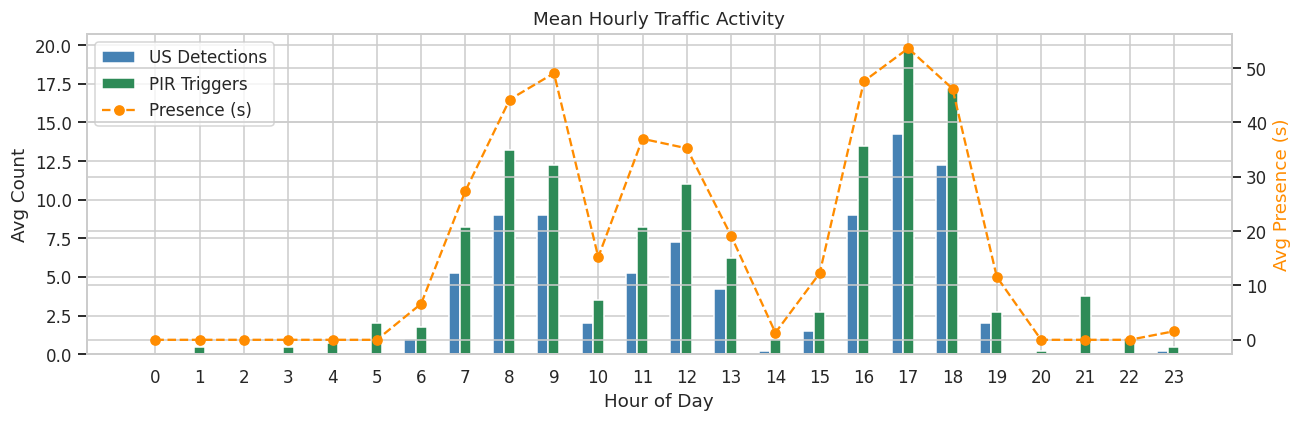

In [5]:
df['hour'] = df.index.hour
hourly = df.groupby('hour')[sensor_cols].mean()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(hourly.index - 0.25, hourly['us_detections'], width=0.25, label='US Detections', color='steelblue')
ax.bar(hourly.index,        hourly['pir_triggers'],  width=0.25, label='PIR Triggers',  color='seagreen')
ax2 = ax.twinx()
ax2.plot(hourly.index, hourly['us_presence_sec'], 'o--', color='darkorange', label='Presence (s)')
ax2.set_ylabel('Avg Presence (s)', color='darkorange')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Avg Count')
ax.set_title('Mean Hourly Traffic Activity')
ax.set_xticks(range(0, 24))
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.tight_layout()
plt.savefig('figures/hourly_pattern.png', bbox_inches='tight')
plt.show()

## 5  Sensor Correlation

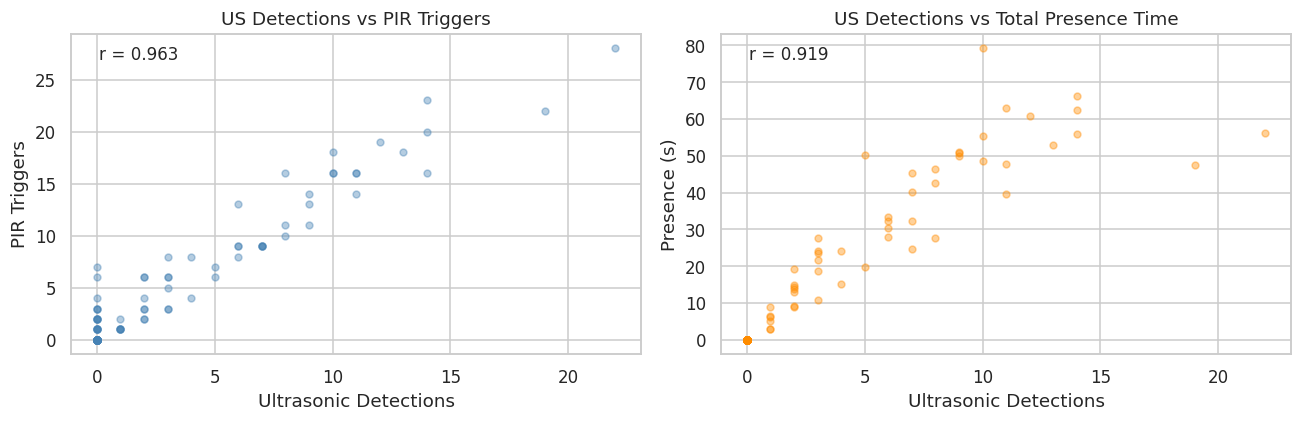


Correlation matrix:


,us_detections,us_presence_sec,pir_triggers
us_detections,1.000,0.919,0.963
us_presence_sec,0.919,1.000,0.914
pir_triggers,0.963,0.914,1.000


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(df['us_detections'], df['pir_triggers'], alpha=0.4, s=20, color='steelblue')
axes[0].set_xlabel('Ultrasonic Detections')
axes[0].set_ylabel('PIR Triggers')
axes[0].set_title('US Detections vs PIR Triggers')
r = df['us_detections'].corr(df['pir_triggers'])
axes[0].annotate(f'r = {r:.3f}', xy=(0.05, 0.92), xycoords='axes fraction', fontsize=11)

axes[1].scatter(df['us_detections'], df['us_presence_sec'], alpha=0.4, s=20, color='darkorange')
axes[1].set_xlabel('Ultrasonic Detections')
axes[1].set_ylabel('Presence (s)')
axes[1].set_title('US Detections vs Total Presence Time')
r2 = df['us_detections'].corr(df['us_presence_sec'])
axes[1].annotate(f'r = {r2:.3f}', xy=(0.05, 0.92), xycoords='axes fraction', fontsize=11)

plt.tight_layout()
plt.savefig('figures/sensor_correlation.png', bbox_inches='tight')
plt.show()

print('\nCorrelation matrix:')
df[sensor_cols].corr().round(3)

## 6  Distribution of Sensor Readings

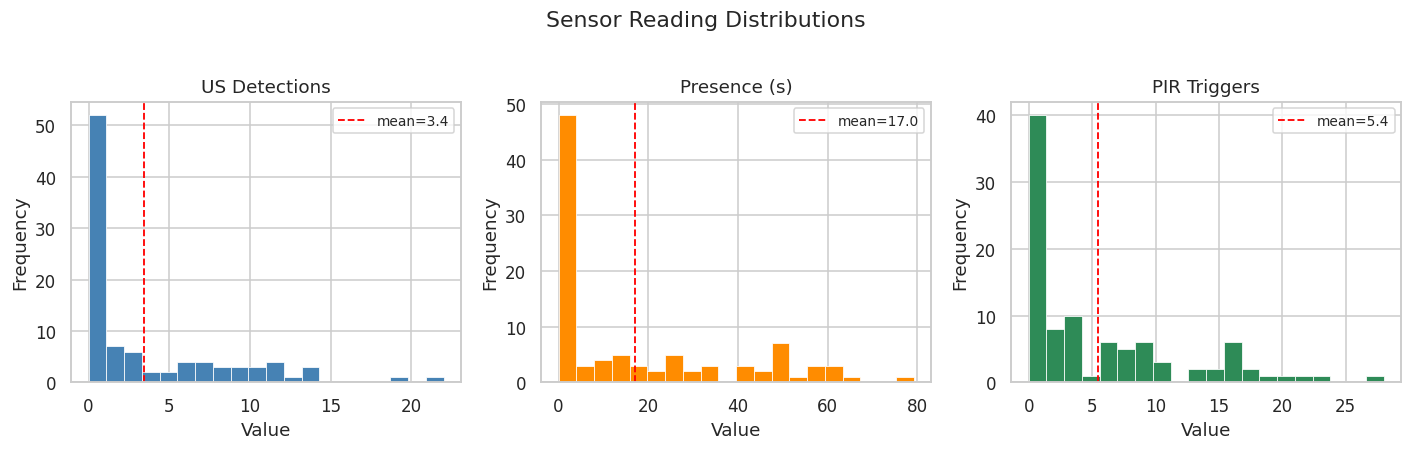

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
colors = ['steelblue', 'darkorange', 'seagreen']
labels = ['US Detections', 'Presence (s)', 'PIR Triggers']

for ax, col, color, label in zip(axes, sensor_cols, colors, labels):
    ax.hist(df[col], bins=20, color=color, edgecolor='white', linewidth=0.5)
    ax.axvline(df[col].mean(), color='red', linestyle='--', linewidth=1.2, label=f'mean={df[col].mean():.1f}')
    ax.set_title(label)
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=9)

plt.suptitle('Sensor Reading Distributions', y=1.02)
plt.tight_layout()
plt.savefig('figures/distributions.png', bbox_inches='tight')
plt.show()

## 7  Key Observations

In [8]:
peak_window = df['us_detections'].idxmax()
quiet_windows = (df['us_detections'] == 0).sum()

print(f"Peak activity window : {peak_window}")
print(f"  US detections at peak : {df.loc[peak_window, 'us_detections']}")
print(f"  PIR triggers at peak  : {df.loc[peak_window, 'pir_triggers']}")
print()
print(f"Zero-detection windows : {quiet_windows} / {len(df)} ({100*quiet_windows/len(df):.1f}%)")
print()
print('Top 5 busiest windows:')
print(df[['us_detections', 'pir_triggers', 'us_presence_sec']].nlargest(5, 'us_detections').to_string())

Peak activity window : 2026-04-24 18:00:00+00:00
  US detections at peak : 22
  PIR triggers at peak  : 28

Zero-detection windows : 46 / 96 (47.9%)

Top 5 busiest windows:
                           us_detections  pir_triggers  us_presence_sec
timestamp                                                              
2026-04-24 18:00:00+00:00             22            28             56.1
2026-04-24 17:30:00+00:00             19            22             47.6
2026-04-24 08:45:00+00:00             14            20             66.3
2026-04-24 17:00:00+00:00             14            16             56.0
2026-04-24 17:45:00+00:00             14            23             62.5
